## **Preprocessing of experimental data (30 subjects) and training of a second artificial neural network**

This notebook is split in two main sections:

1. Preprocessing of EMG and inertial data of 30 subjects while flexing the right wrist. 
2. Training of a second artificial neural network to predict the angular position of the wrist. 

In [1]:
# Import libraries
import numpy as np
from scipy.signal import lfilter
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\dilp9\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Section 1: Preprocessing of data

## 1.1 Moving average filter
What is better? np.convolve or scipy.signal.lfilter

In [2]:
# How to use the moving average filter in python with numpy
# Señal de ejemplo
datos = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18, 20])

# Tamaño de la ventana del promedio móvil
N = 3

# Crear el kernel (ventana con N valores iguales que suman 1)
kernel = np.ones(N) / N

# Aplicar la convolución
# 'valid' asegura que el promedio solo se calcule donde la ventana encaja completamente
promedio_movil = np.convolve(datos, kernel, mode='valid')

print(promedio_movil)
# Resultado: [ 4.  6.  8. 10. 12. 14. 16. 18.]


[ 4.  6.  8. 10. 12. 14. 16. 18.]


In [3]:
# With scipy.signal.lfilter 
# Source: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lfilter.html 

datos = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
ventana = 3

# Crear los coeficientes para el promedio móvil
b = np.ones(ventana) / ventana

# Aplicar el filtro
suavizado = lfilter(b, 1, datos)
print(suavizado)

[ 0.66666667  2.          4.          6.          8.         10.
 12.         14.         16.         18.        ]


## 1.2 Getting a single array for both, EMG and angular position data

In [4]:
# Empty lists for data
EMG_value = []
IMU_value = []

### Subject 1
What it is missing is to convert the amplitude of the EMG data to voltage, and the time as well, because every plot on the x-axis has values from 0 to 100 but considering the ammount of samples of each subject. 

In [5]:
# Prepare data
df= pd.read_csv('1_SubjectsData_EMG_IMU_29Ago25/S1_M_45a_168cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

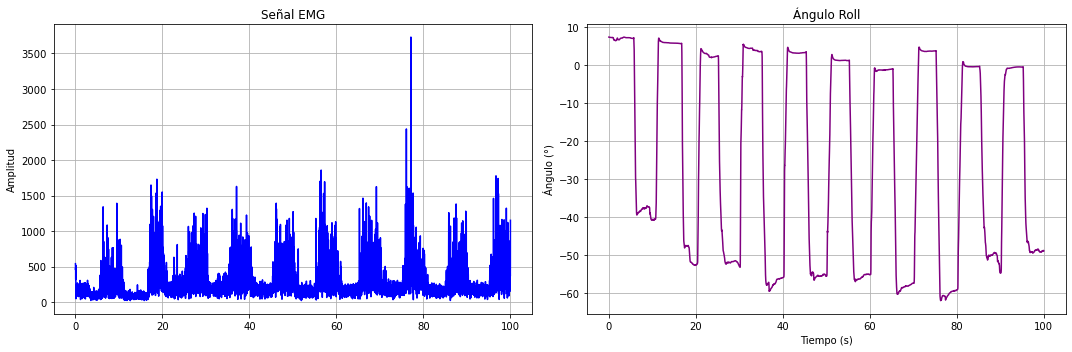

In [6]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()
plt.show()

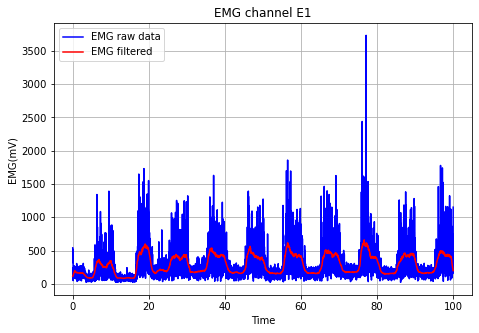

In [7]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [8]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 2

In [9]:
# Prepare data
df= pd.read_csv('1_SubjectsData_EMG_IMU_29Ago25/S2_H_20a_170cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

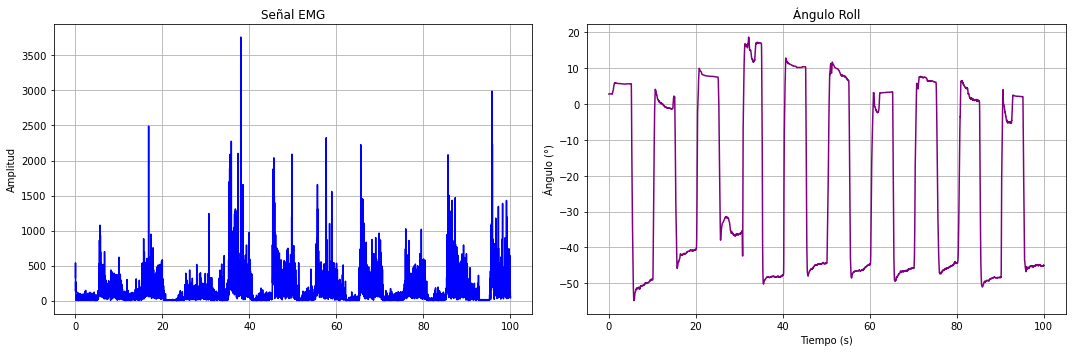

In [10]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()
plt.show()

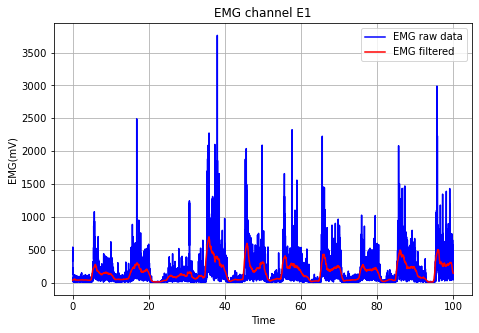

In [11]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [12]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 3

In [13]:
# Prepare data
df= pd.read_csv('1_SubjectsData_EMG_IMU_29Ago25/S3_M_23a_160cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

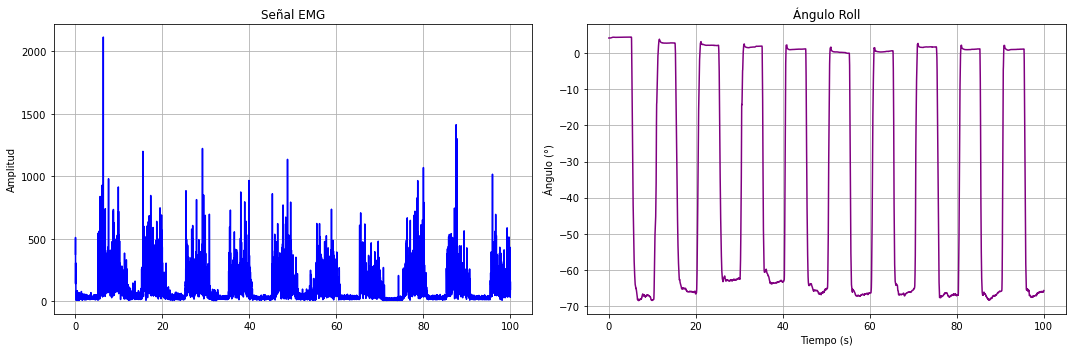

In [14]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

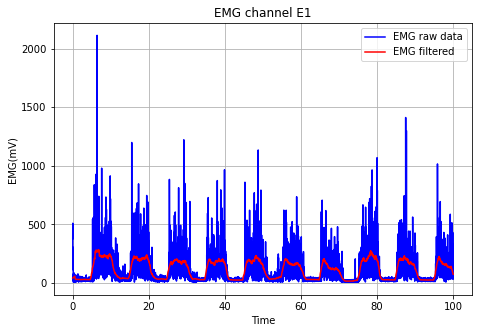

In [15]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [16]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 4

In [17]:
# Prepare data
df= pd.read_csv('1_SubjectsData_EMG_IMU_29Ago25/S4_H_20a_182cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

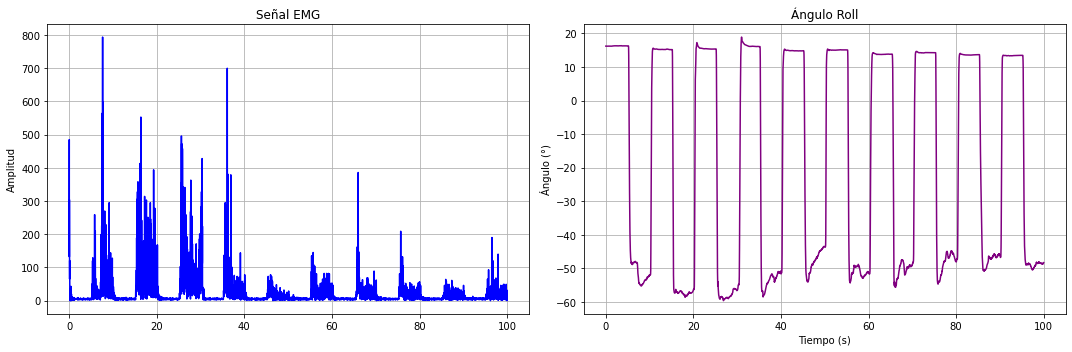

In [18]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

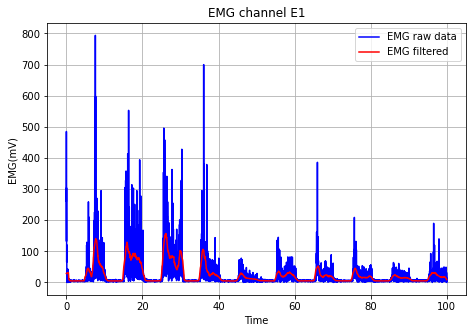

In [19]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [20]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 5 (not used for training!!)

In [21]:
# Prepare data
df= pd.read_csv('1_SubjectsData_EMG_IMU_29Ago25/S5_H_37a_187cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

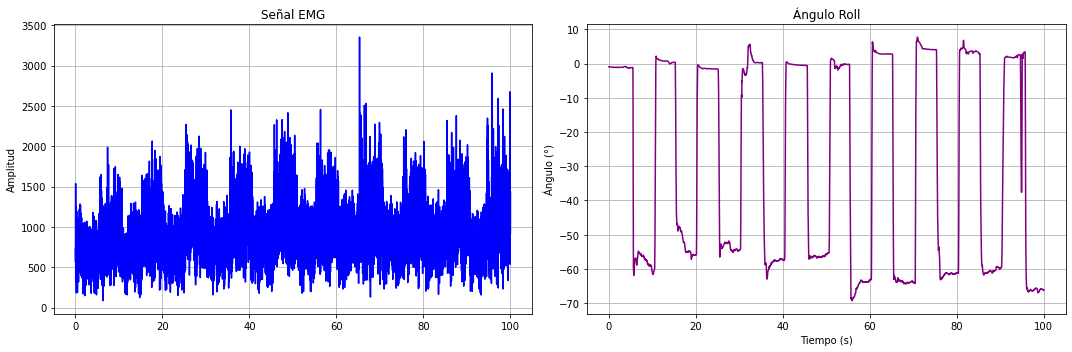

In [22]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

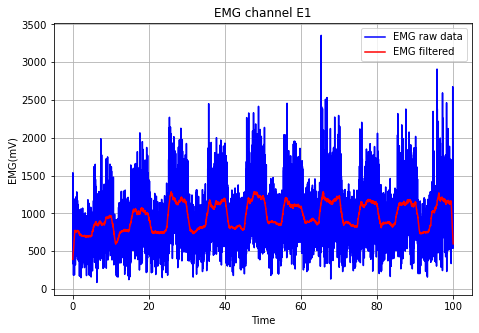

In [23]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

### Subject 6

In [24]:
# Prepare data
df= pd.read_csv('1_SubjectsData_EMG_IMU_29Ago25/S6_M_36_163cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

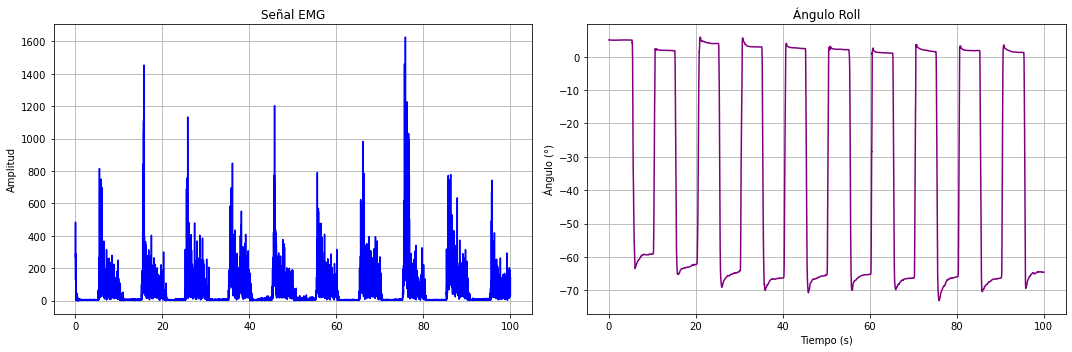

In [25]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

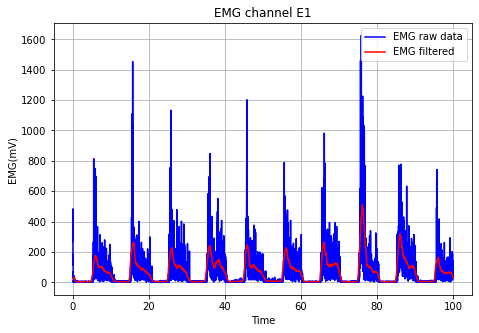

In [26]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [27]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 7

In [28]:
# Prepare data
df= pd.read_csv('1_SubjectsData_EMG_IMU_29Ago25/S7_M_25a_151cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

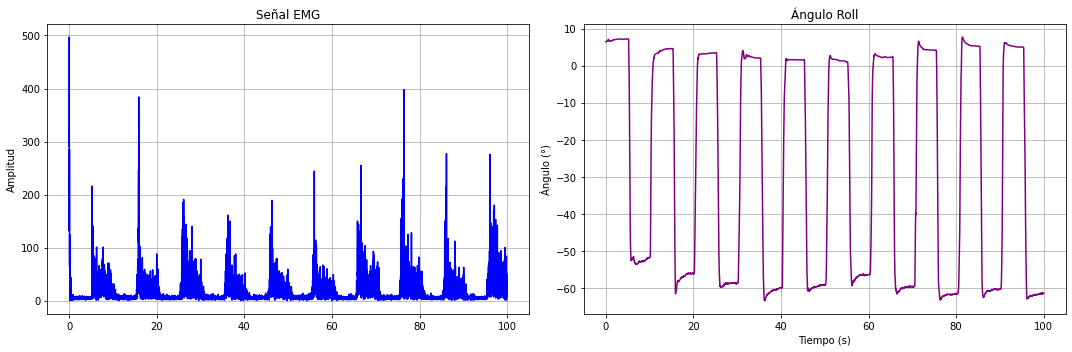

In [29]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

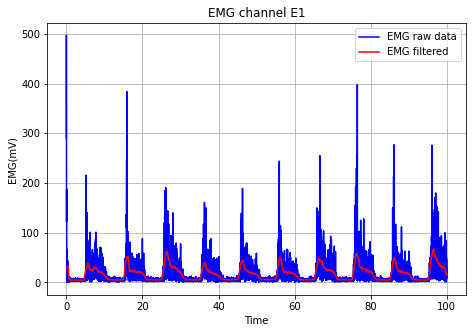

In [30]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [31]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 8 (not used for training)

In [32]:
# Prepare data
df= pd.read_csv('1_SubjectsData_EMG_IMU_29Ago25/S8_M_60a_153cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

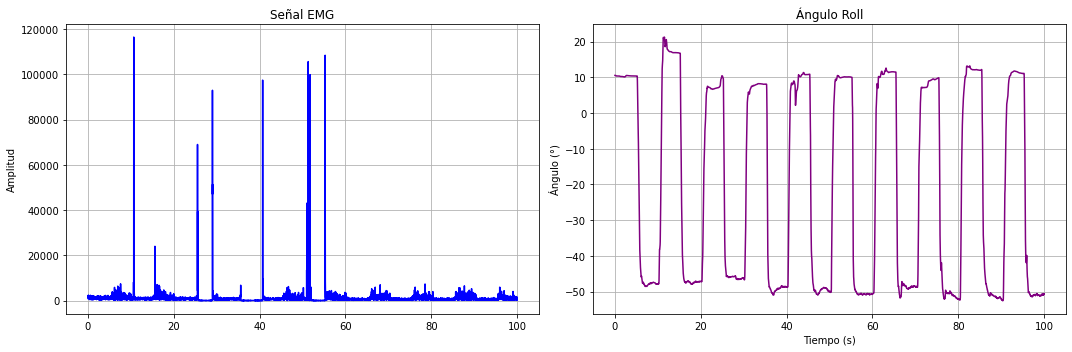

In [33]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

### Subject 9

In [34]:
# Prepare data
df= pd.read_csv('1_SubjectsData_EMG_IMU_29Ago25/S9_H_62a_165cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

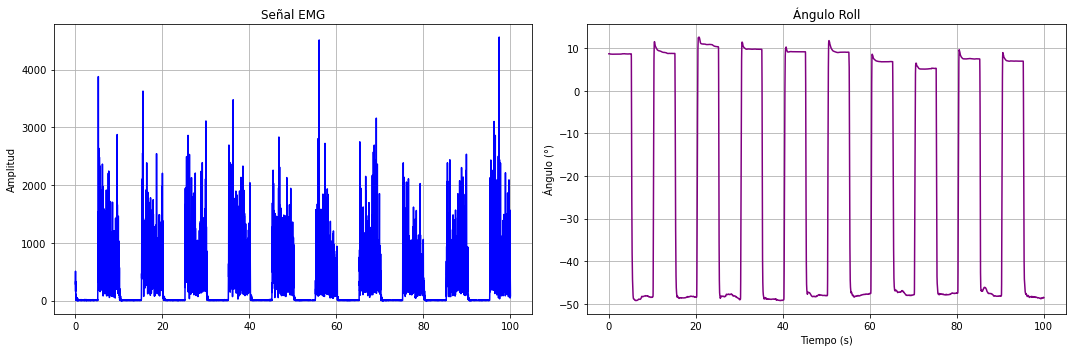

In [35]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

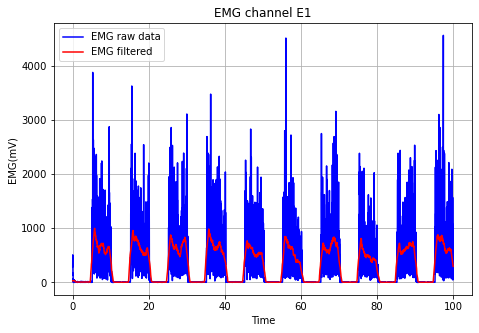

In [36]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [37]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 10

In [38]:
# Prepare data
df= pd.read_csv('2_SubjectsData_Oct/19_Oct/S1_H_30a_170cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

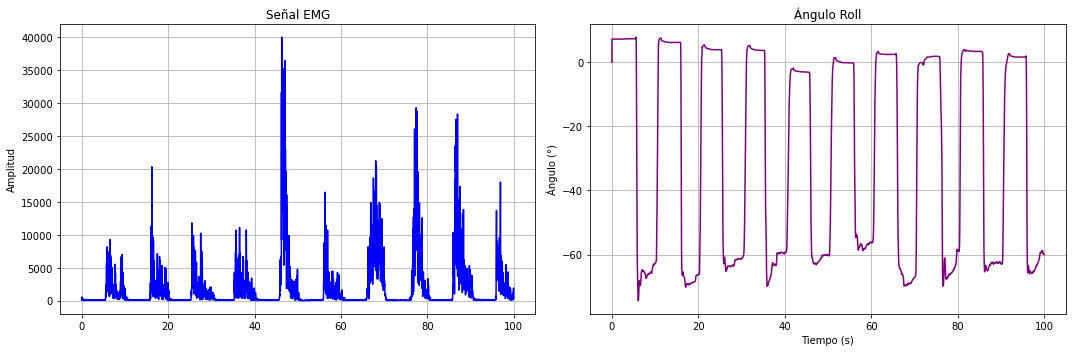

In [39]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

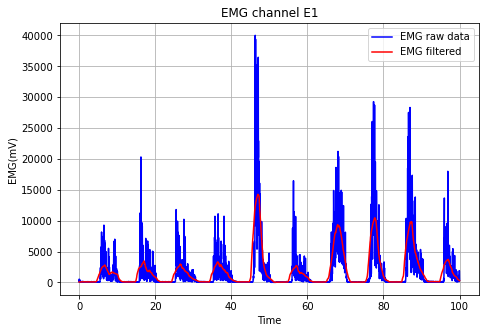

In [40]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [41]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 11

In [42]:
# Prepare data
df= pd.read_csv('2_SubjectsData_Oct/19_Oct/S2_M_30a_160cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

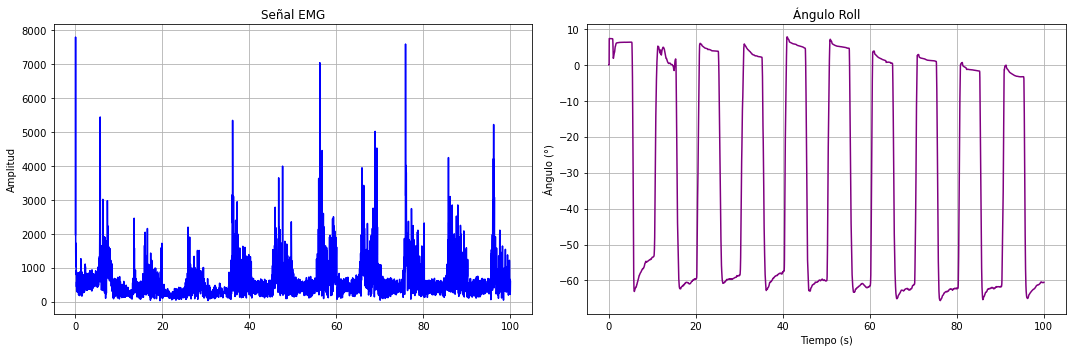

In [43]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

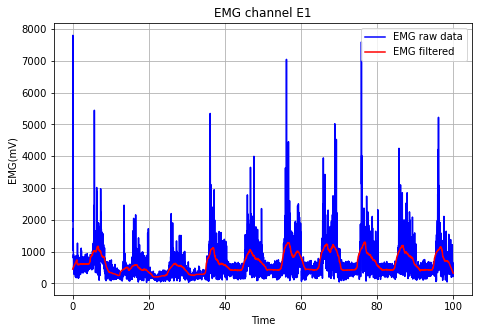

In [44]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [45]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 12

In [46]:
# Prepare data
df= pd.read_csv('2_SubjectsData_Oct/19_Oct/S3_M_25a_168cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

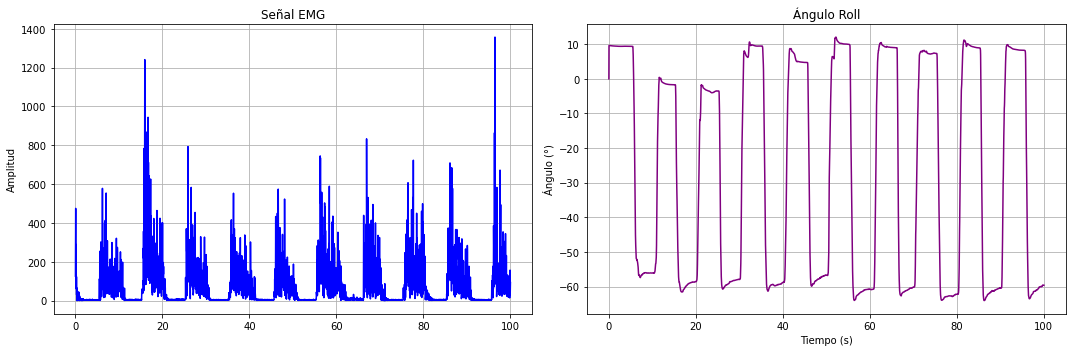

In [47]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

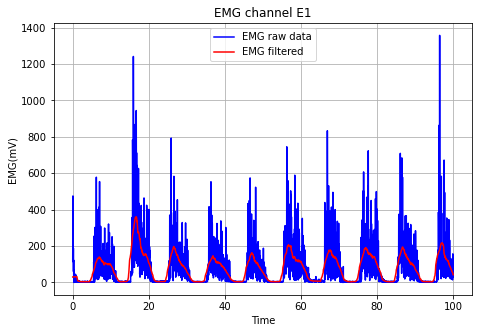

In [48]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [49]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 13

In [50]:
# Prepare data
df= pd.read_csv('2_SubjectsData_Oct/19_Oct/S4_H_27a_170cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

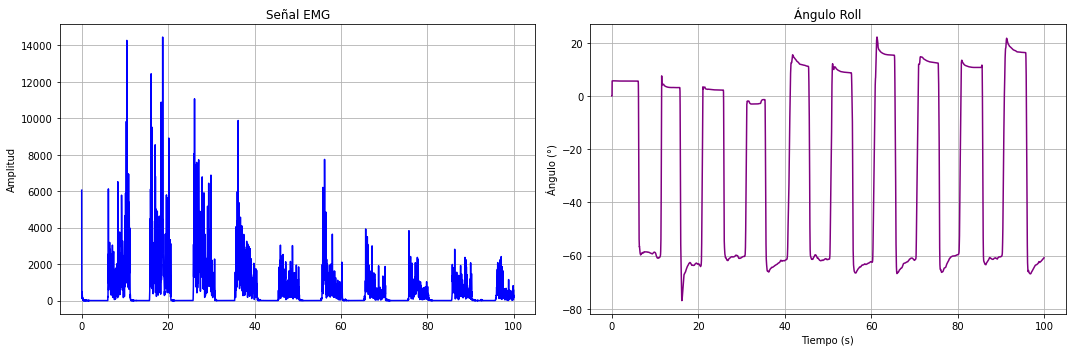

In [51]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

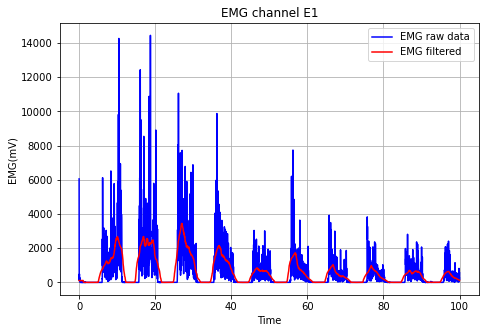

In [52]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [53]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 14

In [54]:
# Prepare data
df= pd.read_csv('2_SubjectsData_Oct/19_Oct/S5_M_33a_175cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

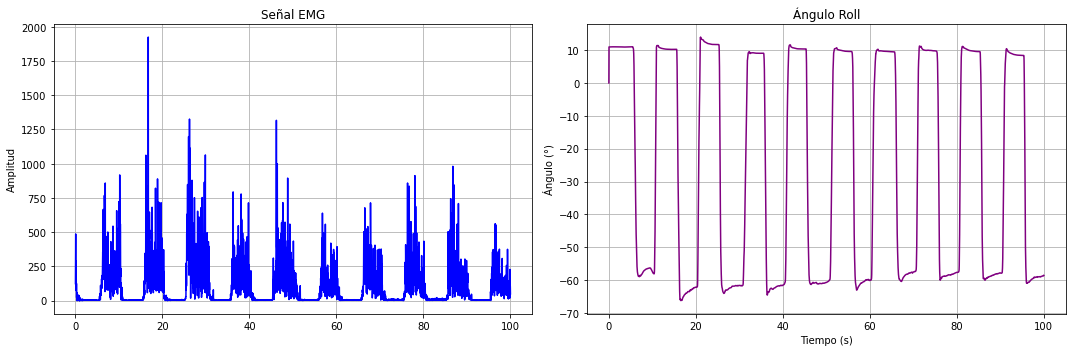

In [55]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

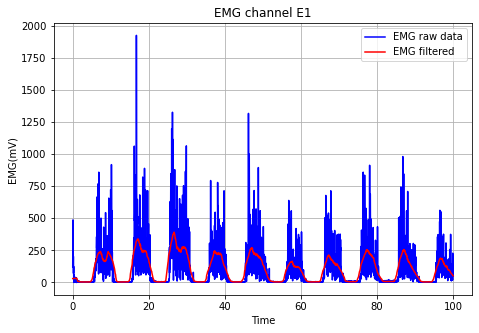

In [56]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [57]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 15

In [58]:
# Prepare data
df= pd.read_csv('2_SubjectsData_Oct/20_Oct/S1_H_22a_170cm.csv')

df_emg = df["EMG"]  
df_roll = df["Roll"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

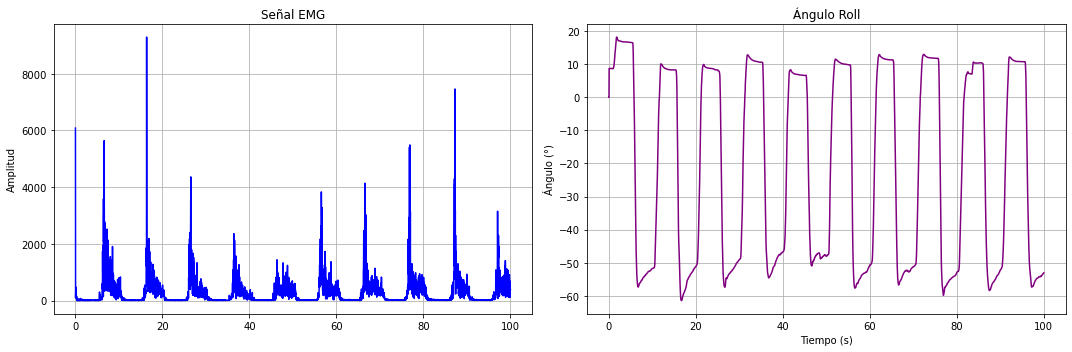

In [59]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

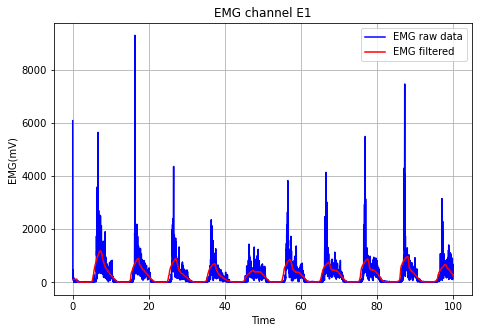

In [60]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [61]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 16
From here, the DAQ prototype did not work properly so I stuck with the 2 sensors and the ESP32 connected to the breadboard. Because of this I switch to use the angle variation from "Roll" to "Pitch"

In [62]:
# Prepare data
df= pd.read_csv('3_SubjectsData_24Apr_26/S1_H_31a_157cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

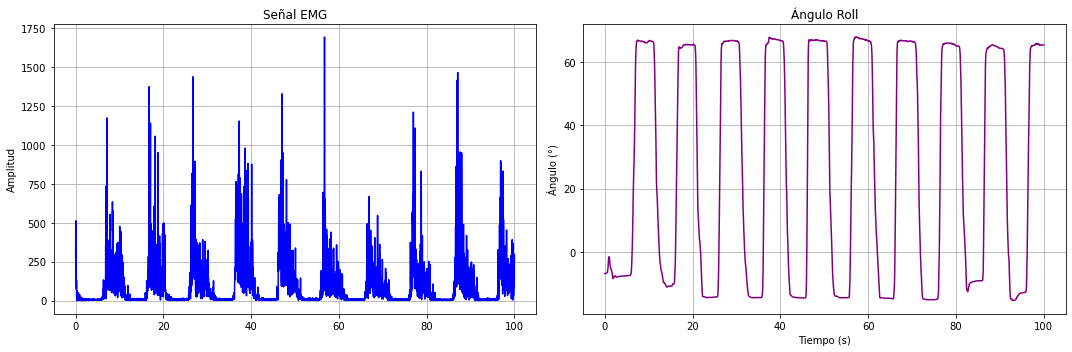

In [63]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

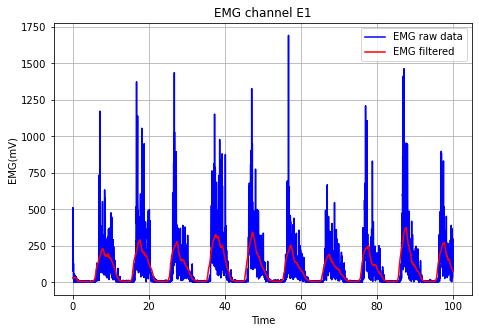

In [64]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [65]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 17

In [66]:
# Prepare data
df= pd.read_csv('3_SubjectsData_24Apr_26/S2_H_20a_174cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

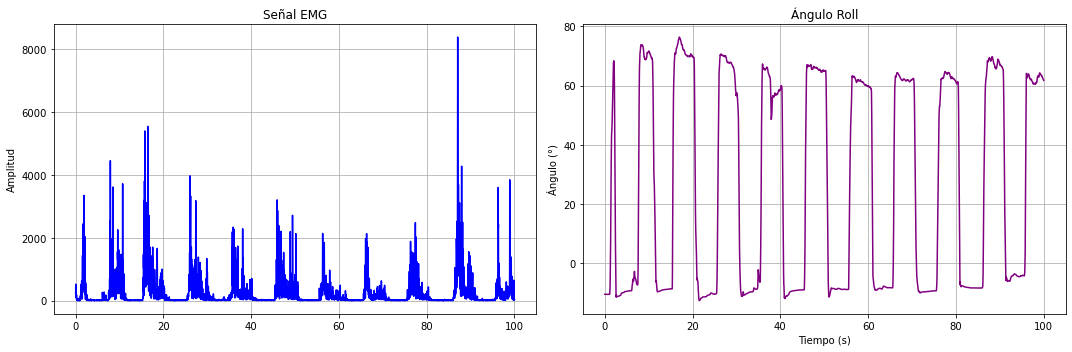

In [67]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

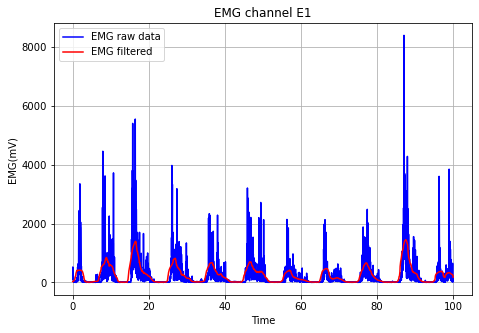

In [68]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [69]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 18

In [70]:
# Prepare data
df= pd.read_csv('3_SubjectsData_24Apr_26/S3_H_21a_182cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

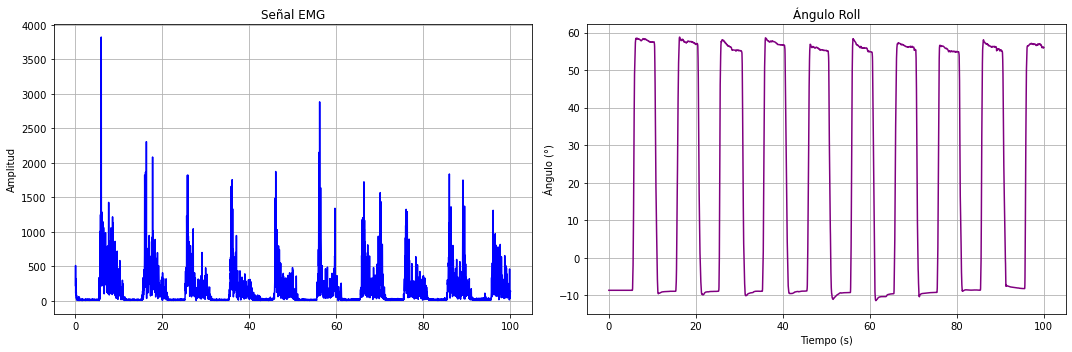

In [71]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

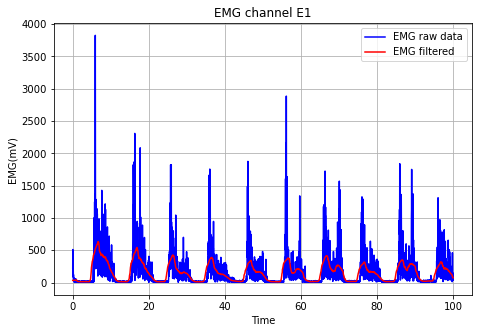

In [72]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [73]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 19

In [74]:
# Prepare data
df= pd.read_csv('3_SubjectsData_24Apr_26/S4_H_22a_180cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

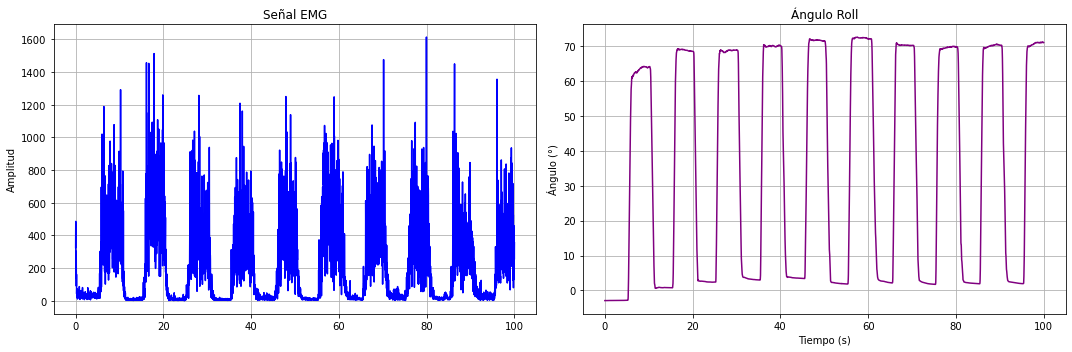

In [75]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

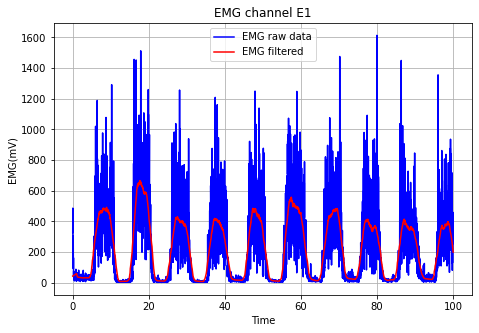

In [76]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

In [77]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 20

In [78]:
# Prepare data
df= pd.read_csv('3_SubjectsData_24Apr_26/S5_H_22a_177cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

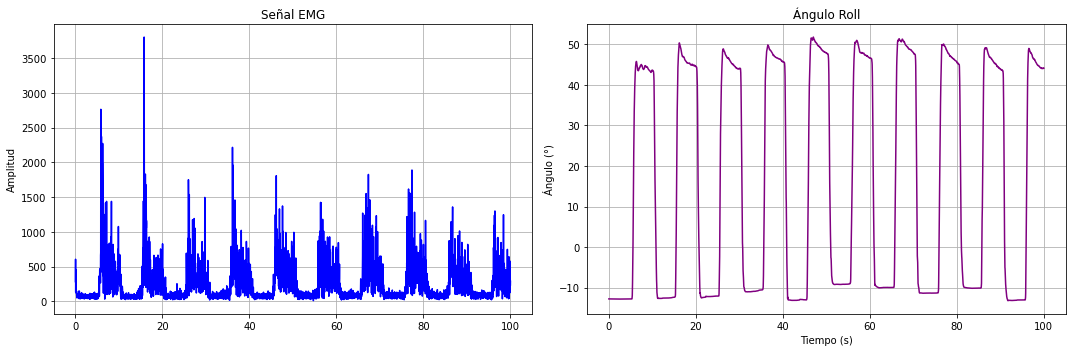

In [79]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

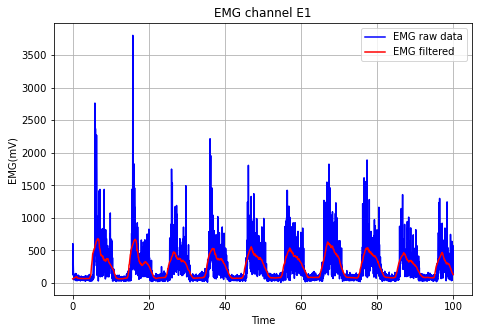

In [80]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula

In [81]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 21

In [82]:
# Prepare data
df= pd.read_csv('3_SubjectsData_24Apr_26/S6_M_35a_155cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

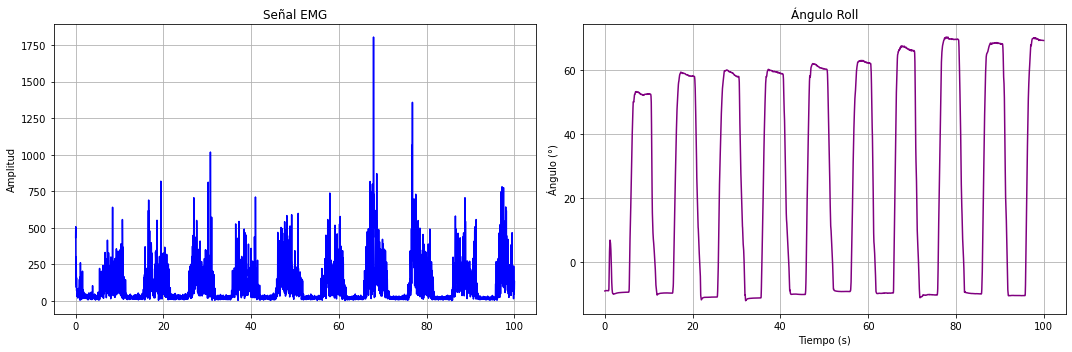

In [83]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

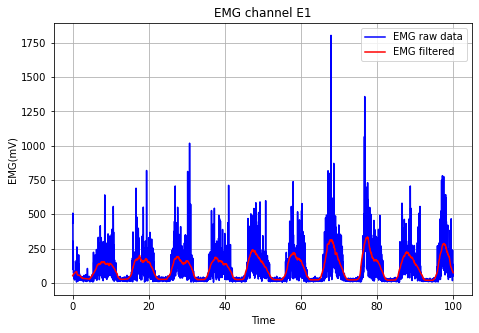

In [84]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula

In [85]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 22 (not used for training!)

In [86]:
# Prepare data
df= pd.read_csv('3_SubjectsData_24Apr_26/S7_H_26a_178cm_checkEMGvalues.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

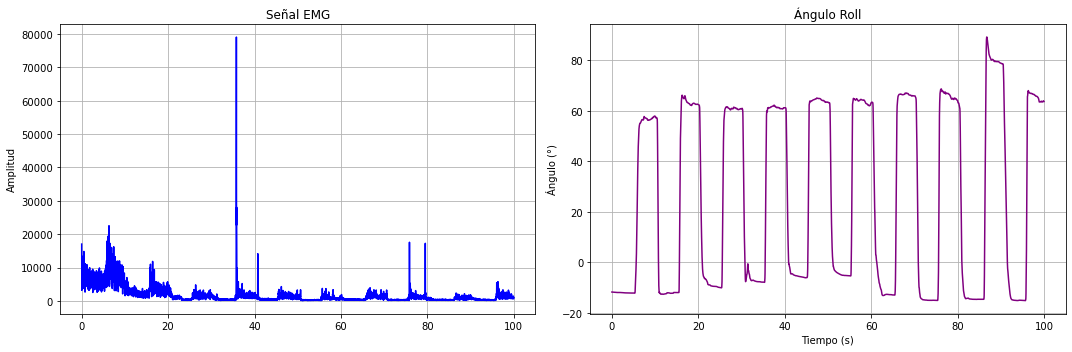

In [87]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

### Subject 23

In [88]:
# Prepare data
df= pd.read_csv('4_SubjectsData_26Apr26/S1_H_7a_130cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

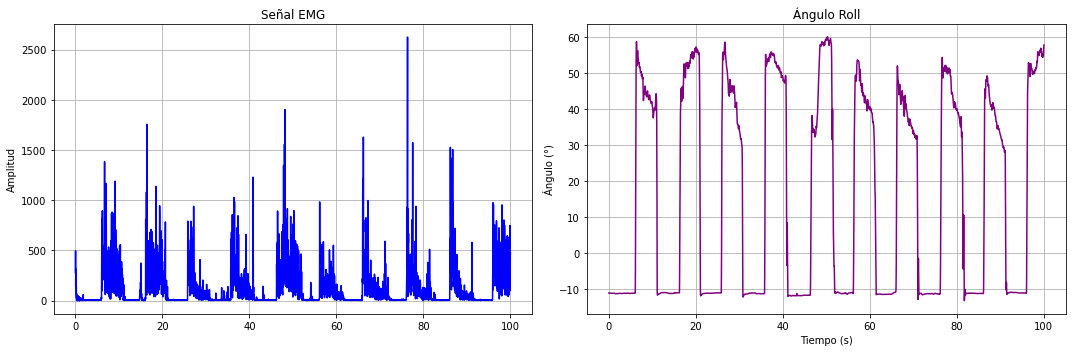

In [89]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

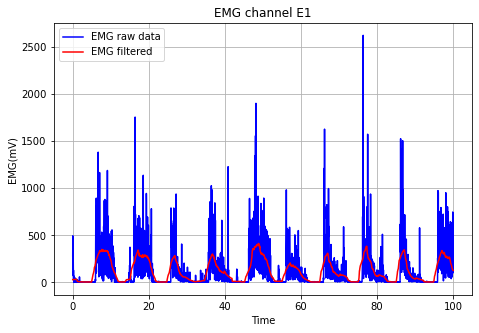

In [90]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula

In [91]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 24

In [92]:
# Prepare data
df= pd.read_csv('4_SubjectsData_26Apr26/S2_H_27a_185cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

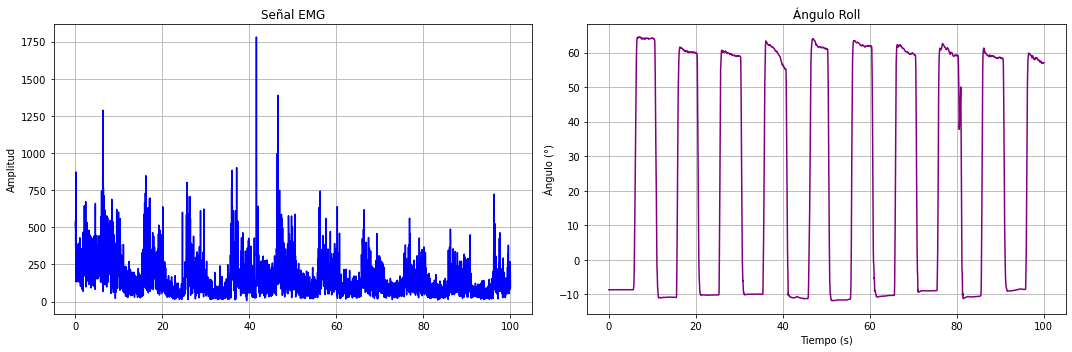

In [93]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

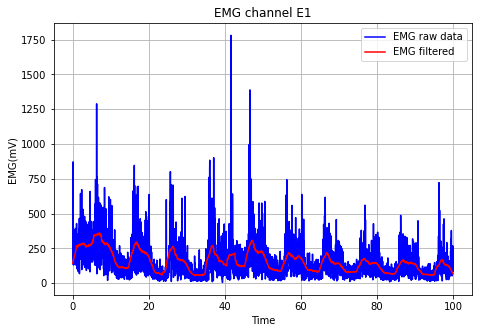

In [94]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula

In [95]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 25

In [96]:
# Prepare data
df= pd.read_csv('4_SubjectsData_26Apr26/S3_M_29a_145cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

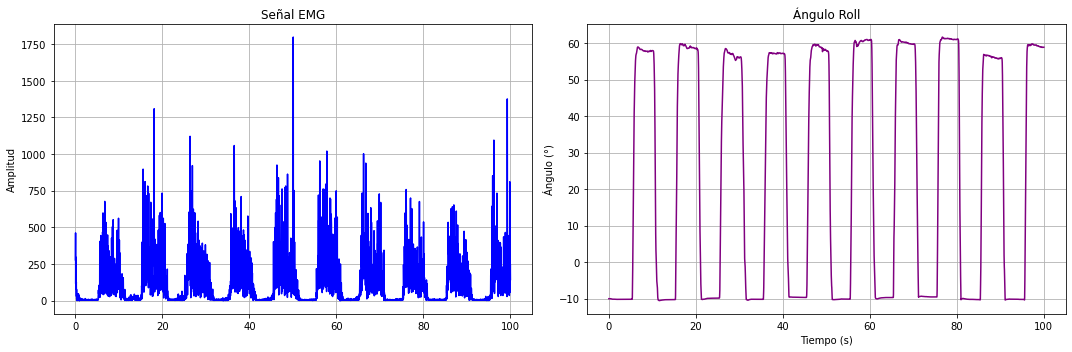

In [97]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

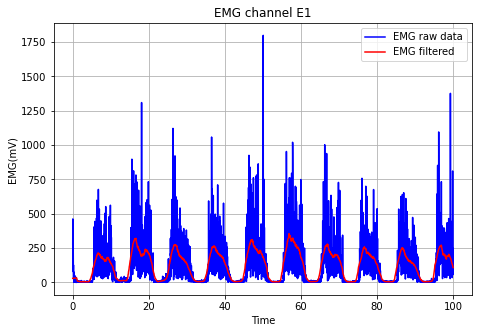

In [98]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula

In [99]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 26

In [100]:
# Prepare data
df= pd.read_csv('4_SubjectsData_26Apr26/S4_H_64a_187cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

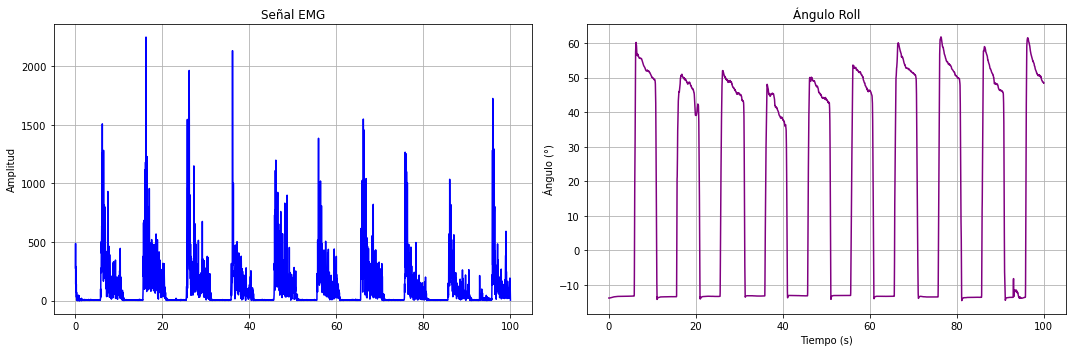

In [101]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

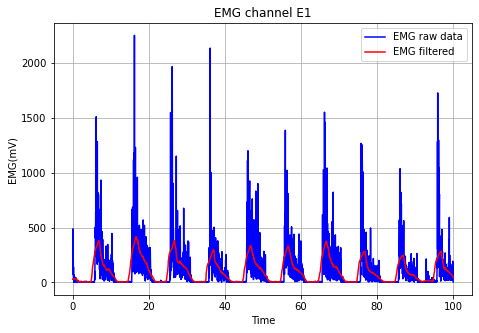

In [102]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula

In [103]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 27

In [104]:
# Prepare data
df= pd.read_csv('4_SubjectsData_26Apr26/S5_M_57a_162cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

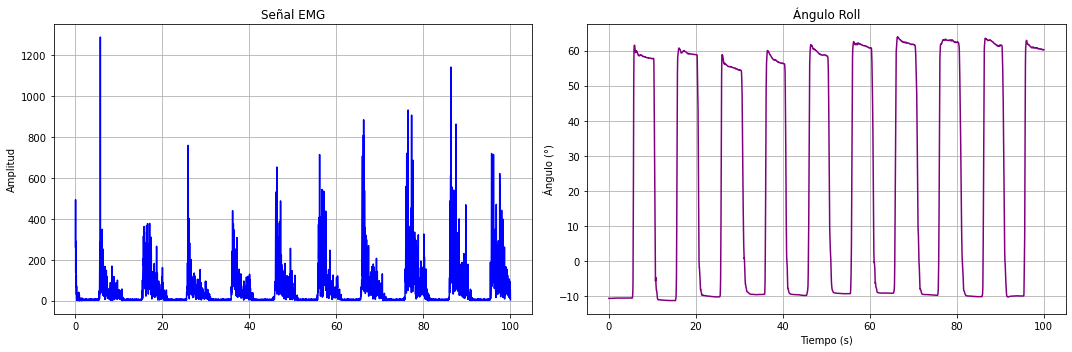

In [105]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

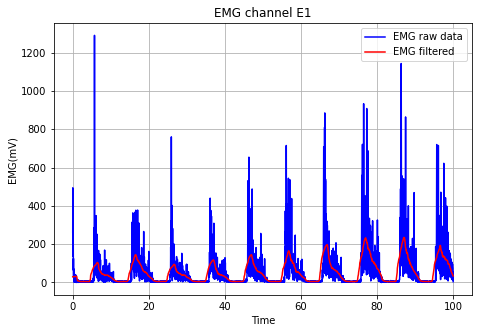

In [106]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula

In [107]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 28

In [108]:
# Prepare data
df= pd.read_csv('4_SubjectsData_26Apr26/S6_M_36a_180cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

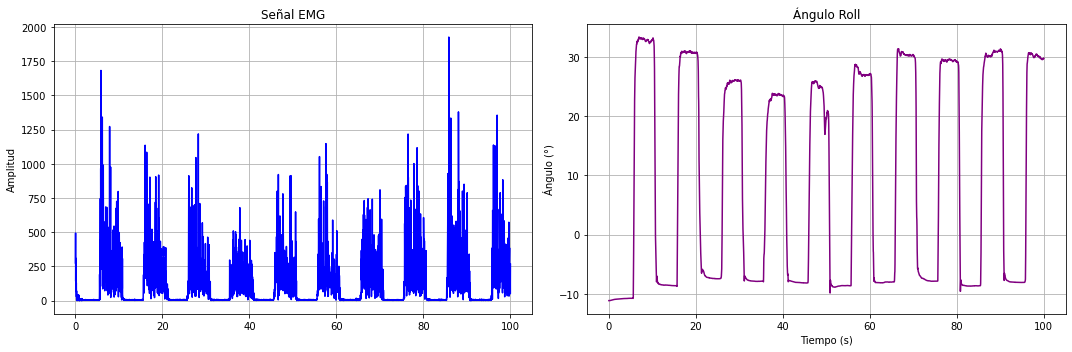

In [109]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

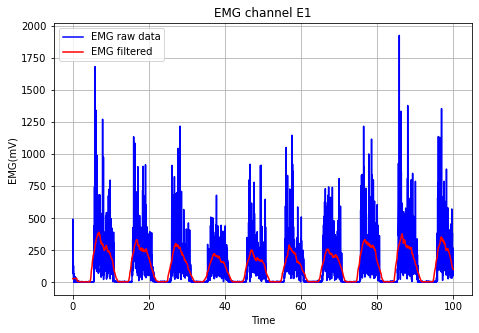

In [110]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula

In [111]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

In [112]:
len(EMG_value)

111063

### Subject 29

In [113]:
# Prepare data
df= pd.read_csv('5_SubjectsData_19_jun_26/S1_M_40a_156cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

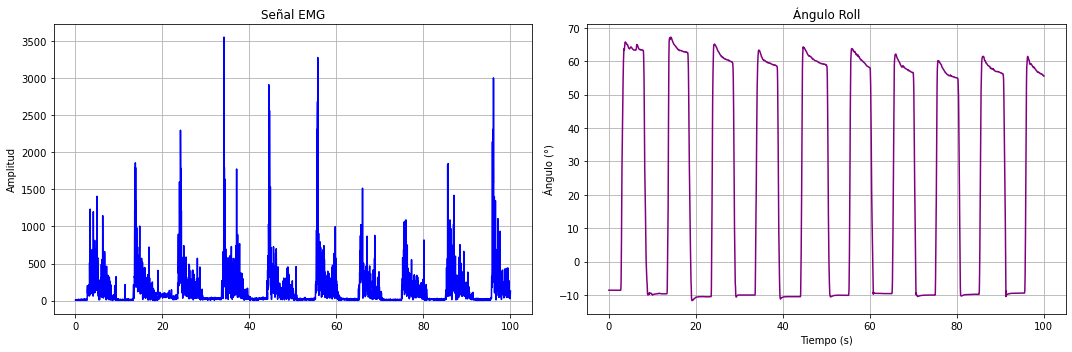

In [114]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

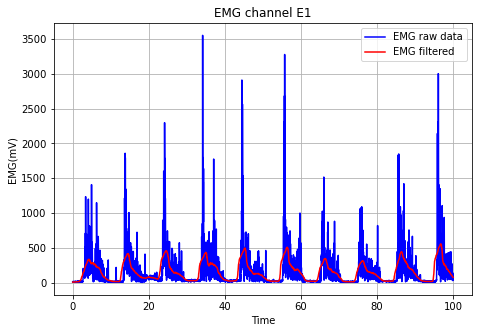

In [115]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula

In [116]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 30

In [117]:
# Prepare data
df= pd.read_csv('5_SubjectsData_19_jun_26/S2_H_43a_169cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

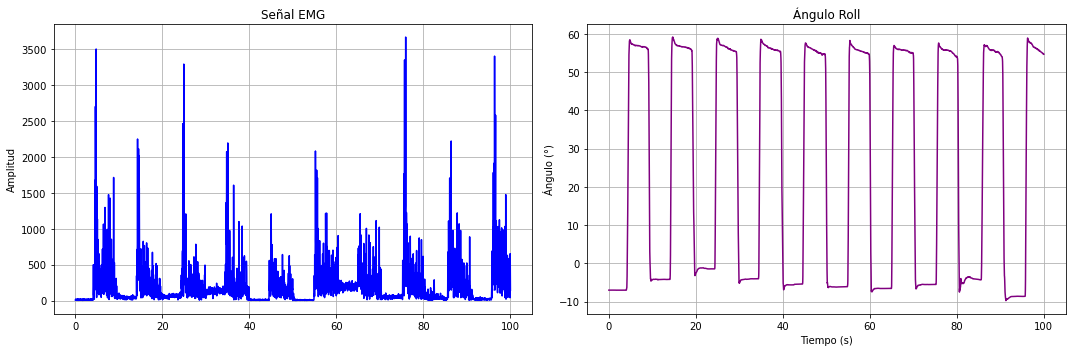

In [118]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

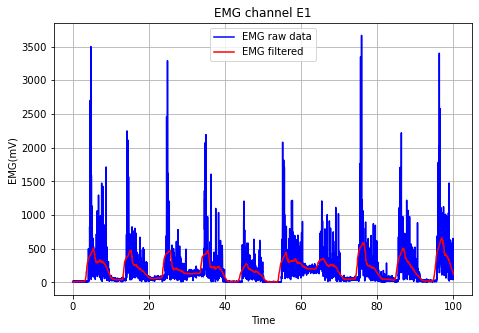

In [119]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula

In [120]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 31

In [123]:
# Prepare data
df= pd.read_csv('5_SubjectsData_19_jun_26/S3_H_28a_170cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

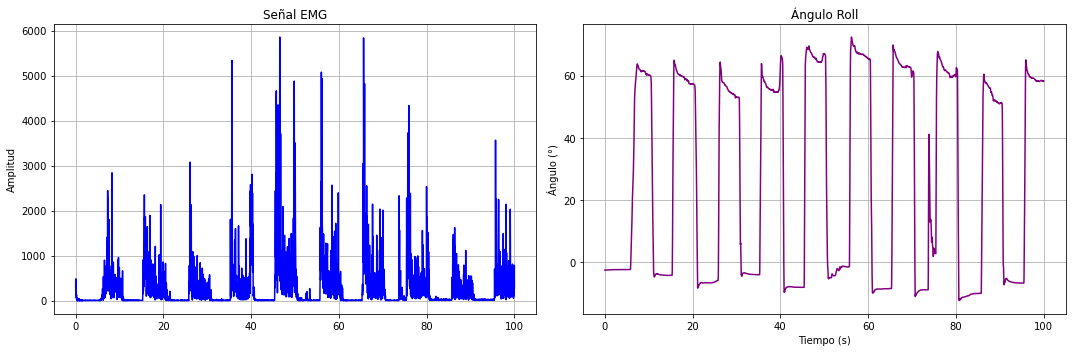

In [124]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

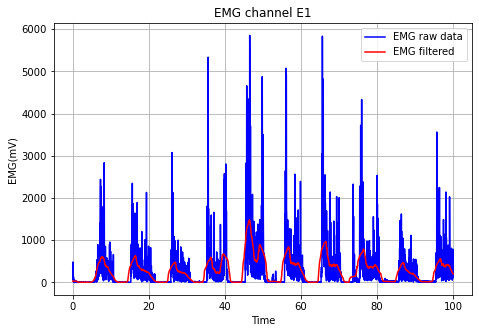

In [125]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula

In [126]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 32

In [127]:
# Prepare data
df= pd.read_csv('5_SubjectsData_19_jun_26/S4_H_34a_172cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

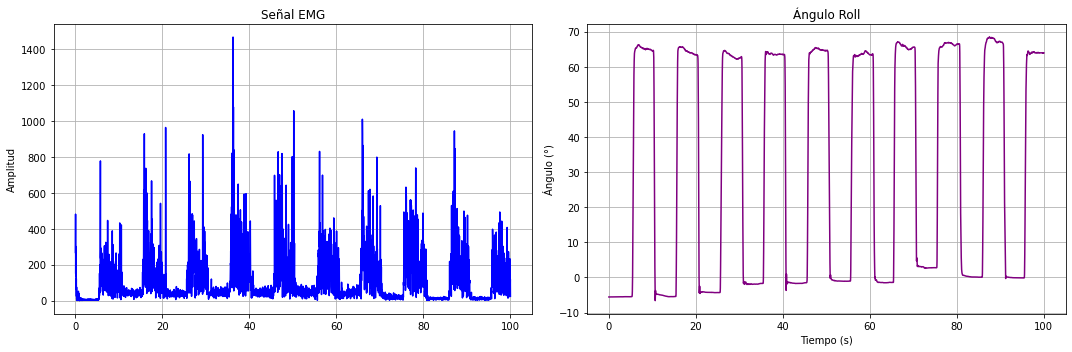

In [128]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

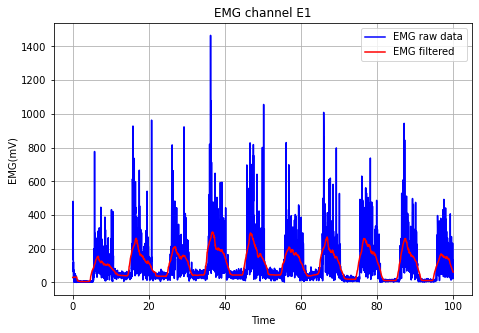

In [129]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula

In [130]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### Subject 33

In [133]:
# Prepare data
df= pd.read_csv('6_SubjectData_22_Jun_26/S1_M_33a_173cm.csv')

df_emg = df["EMG"]  
df_roll = df["Pitch"]

x = np.linspace(0, 100, len(df_emg))  # Genera 16361 puntos entre 0 y 100
y = df_emg

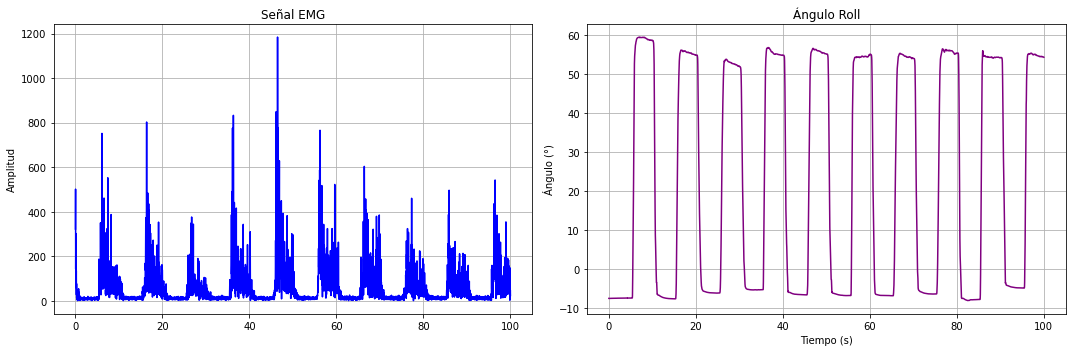

In [134]:
# Crear la figura con 2 subplots (verticales)
fig, axs = plt.subplots(1,2, figsize=(15, 5), sharex=True)

# Primer subplot: EMG
axs[0].plot(x, df_emg, color='b')
axs[0].set_title("Señal EMG")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)  # activar grid

# Segundo subplot: Roll
axs[1].plot(x, df_roll, color='purple')
axs[1].set_title("Ángulo Roll")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Ángulo (°)")
axs[1].grid(True)  # activar grid

# Ajustar espacios
plt.tight_layout()

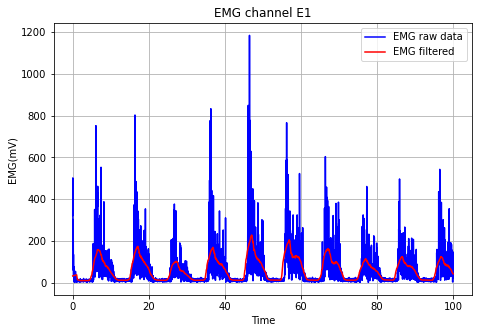

In [135]:
# Preprocessing: Moving averge filter

signal = y

# Define window size (75 muestras)
window_size = 75
window = np.ones(window_size) / window_size 

# Apply Moving averge filter
filtered_signal = np.convolve(signal, window, mode='same')

plt.figure(figsize=(7.5, 5))  

plt.plot(x, y, label="EMG raw data", color='b')  # Dibuja el gráfico
plt.plot(x, filtered_signal, label="EMG filtered", color="red")  # Dibuja el gráfico
plt.title("EMG channel E1")  # Título
plt.xlabel("Time")  # Etiqueta del eje x
plt.ylabel("EMG(mV)")  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda
plt.grid(True)  # Muestra la cuadrícula

In [136]:
# Add values to a single vector

for a, b in zip(filtered_signal, df_roll):
    EMG_value.append(a)
    IMU_value.append(b)

### 1.3 Data normalization

In [146]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [152]:
#Normalización de datos EMG

# Convertir lista a un arreglo de Numpy
emg_array = np.array(EMG_value)

# Cambiar la forma a una matriz de (N, 1)
emg_2d = emg_array.reshape(-1, 1)

# Determinar la escala 
scaler = MinMaxScaler(feature_range=(0, 1))

# Normalizar la señal con el escalador
emg_normalizada = scaler.fit_transform(emg_2d)

In [154]:
#Normalización de datos inerciales (IMU)

# Convertir lista a un arreglo de Numpy
IMU_array = np.array(IMU_value)

# Cambiar la forma a una matriz de (N, 1)
IMU_2d = IMU_array.reshape(-1, 1)

# Determinar la escala 
# Recordatorio: en el scaler se guardan los valores mínimos y máximos del rango para que 
# la predicción de la red se pueda transformar a la posición angular real con  
# Desnormalizar para obtener los grados reales originales

#angulo_en_grados = scaler_angulo.inverse_transform(prediccion_red)
scaler = MinMaxScaler(feature_range=(0, 1))

# Normalizar la señal con el escalador
IMU_normalizada = scaler.fit_transform(IMU_2d)

### 1.4 Dataset division: training and testing groups
It is better to split from the beginning until the 80% of the array.

In [160]:
# 1. Definir la proporción de entrenamiento
porcentaje_train = 0.80

# 2. Calcular el índice exacto donde se cortará la serie de tiempo
limite_division = int(len(emg_normalizada) * porcentaje_train)

# 3. Conjunto de Entrenamiento (Primeros 8 minutos, por ejemplo)
X_train_continuo = emg_normalizada[:limite_division]
y_train_continuo = IMU_normalizada[:limite_division]

# 4. Conjunto de Prueba / Test (Últimos 2 minutos de la sesión)
X_test_continuo = emg_normalizada[limite_division:]
y_test_continuo = IMU_normalizada[limite_division:]

# ==============================================================================
# VERIFICACIÓN DE LAS DIMENSIONES
# ==============================================================================
print("--- Verificación de Divisiones de Datos ---")
print(f"Total de muestras en el experimento: {len(emg_normalizada)}")
print(f"Índice de corte: {limite_division}\n")

print(f"X_train (EMG Entrenamiento): {X_train_continuo.shape}")
print(f"y_train (IMU Entrenamiento): {y_train_continuo.shape}\n")

print(f"X_test  (EMG Prueba):        {X_test_continuo.shape}")
print(f"y_test  (IMU Prueba):        {y_test_continuo.shape}")

--- Verificación de Divisiones de Datos ---
Total de muestras en el experimento: 128761
Índice de corte: 103008

X_train (EMG Entrenamiento): (103008, 1)
y_train (IMU Entrenamiento): (103008, 1)

X_test  (EMG Prueba):        (25753, 1)
y_test  (IMU Prueba):        (25753, 1)


### 1.5 Windowing the entire dataset
In "Regression convolutional neural network for improved simultaneous EMG control,2019" (https://iopscience.iop.org/article/10.1088/1741-2552/ab0e2e/meta) They split the signal in windows of 200 samples. 
I propose to do the same with 200 samples of the signal in the time domain. 

In "Myoelectric Control for Upper Limb Prostheses, 2019" (https://www.mdpi.com/2079-9292/8/11/1244) They talk with a general perspective about the windowing process. They mention two methodologies, adjacent and overlaped windowing. 

I also have to do an overlap during the trainig of the CNN, maybe 50 ms?

In [161]:
# 1. Definición limpia de la función (sin números fijos)
def segmentar_en_ventanas(datos_emg, datos_imu, tamano_ventana, desplazamiento):
    X_ventanas = []
    y_valores = []
    for i in range(0, len(datos_emg) - tamano_ventana + 1, desplazamiento):
        X_ventanas.append(datos_emg[i : i + tamano_ventana])
        y_valores.append(datos_imu[i + tamano_ventana - 1])
    return np.array(X_ventanas), np.array(y_valores)

# 2. Las únicas constantes de tu proyecto (las cambias aquí y afectan a todo)
TAMANO_VENTANA = 200  
DESPLAZAMIENTO = 50   

# 3. Llamada usando tus constantes
X_train, y_train = segmentar_en_ventanas(X_train_continuo, y_train_continuo, TAMANO_VENTANA, DESPLAZAMIENTO)
X_test, y_test = segmentar_en_ventanas(X_test_continuo, y_test_continuo, TAMANO_VENTANA, DESPLAZAMIENTO)

# ==============================================================================
# VERIFICACIÓN DE LAS DIMENSIONES FINALES
# ==============================================================================
print("--- Dimensiones Finales para la CNN 1D ---")
print(f"X_train (Entrenamiento): {X_train.shape} -> (Ventanas, Muestras por ventana, Canales)")
print(f"y_train (Etiquetas):     {y_train.shape} -> (Ventanas, Ángulo objetivo)")
print("-" * 50)
print(f"X_test  (Prueba):        {X_test.shape}")
print(f"y_test  (Etiquetas):     {y_test.shape}")

--- Dimensiones Finales para la CNN 1D ---
X_train (Entrenamiento): (2057, 200, 1) -> (Ventanas, Muestras por ventana, Canales)
y_train (Etiquetas):     (2057, 1) -> (Ventanas, Ángulo objetivo)
--------------------------------------------------
X_test  (Prueba):        (512, 200, 1)
y_test  (Etiquetas):     (512, 1)


## Section 2: Training of a CNN 

In [162]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [170]:
tf.keras.backend.clear_session()

modelo_emg = models.Sequential(name="CNN1D_Regresion_Muneca")

# 1. Primera Convolución 1D (Usa tus datos de las celdas anteriores)
modelo_emg.add(layers.Conv1D(filters=32, kernel_size=11, activation='relu', 
                             input_shape=(TAMANO_VENTANA, 1), padding='same'))
modelo_emg.add(layers.MaxPooling1D(pool_size=2))

# 2. Segunda Capa Convolucional 1D
modelo_emg.add(layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'))
modelo_emg.add(layers.MaxPooling1D(pool_size=2))

# 3. Tercera Capa Convolucional 1D
modelo_emg.add(layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))

# 4. Reducción Global
modelo_emg.add(layers.GlobalAveragePooling1D())

# 5. Capa Densa de Abstracción
modelo_emg.add(layers.Dense(64, activation='relu'))
modelo_emg.add(layers.Dropout(0.2))

# 6. CAPA DE SALIDA: 1 sola neurona lineal para el ángulo
modelo_emg.add(layers.Dense(1, activation='linear', name="Salida_Angulo"))

# ==============================================================================
# COMPILACIÓN DEL MODELO
# ==============================================================================
modelo_emg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(), 
    metrics=['mae']
)

# Mostrar la estructura del modelo
modelo_emg.summary()

Model: "CNN1D_Regresion_Muneca"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 200, 32)             │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 100, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 100, 64)             │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 50, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 50, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Salida_Angulo (Dense)                │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,713 (170.75 KB)

 Trainable params: 43,713 (170.75 KB)

 Non-trainable params: 0 (0.00 B)

In [164]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0743 - mae: 0.3089 - val_loss: 0.0574 - val_mae: 0.2695
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0342 - mae: 0.2130 - val_loss: 0.0435 - val_mae: 0.2173
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0333 - mae: 0.2057 - val_loss: 0.0512 - val_mae: 0.2444
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0328 - mae: 0.2037 - val_loss: 0.0371 - val_mae: 0.2052
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0341 - mae: 0.2102 - val_loss: 0.0479 - val_mae: 0.2314
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0341 - mae: 0.2095 - val_loss: 0.0358 - val_mae: 0.2038
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0336 - mae: 0.2081 - val_loss: 0.0419 - val_mae: 0.2126
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0325 - mae: 0.2060 - val_loss: 0.0388 - val_mae: 0.2079
Epoch 9/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - lo

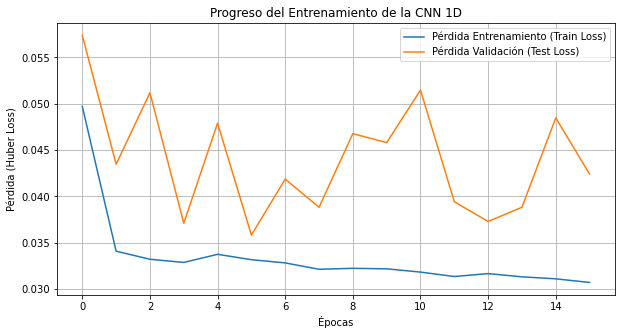

In [171]:
# Definir EarlyStopping para detener el entrenamiento de forma inteligente
callback_parar_temprano = EarlyStopping(
    monitor='val_loss',     # Monitorea la pérdida en el set de prueba
    patience=10,            # Si durante 10 épocas seguidas no mejora, se detiene
    restore_best_weights=True # Se queda con los mejores pesos guardados
)

# Ejecutar el entrenamiento
historial = modelo_emg.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,              # Límite máximo de vueltas completas al dataset
    batch_size=32,           # Cuántas ventanas procesa antes de actualizar pesos
    callbacks=[callback_parar_temprano],
    verbose=1                # Muestra el progreso en la pantalla paso a paso
)

# ==============================================================================
# GRÁFICA DE RENDIMIENTO (CURVA DE APRENDIZAJE)
# ==============================================================================
plt.figure(figsize=(10, 5))
plt.plot(historial.history['loss'], label='Pérdida Entrenamiento (Train Loss)')
plt.plot(historial.history['val_loss'], label='Pérdida Validación (Test Loss)')
plt.title('Progreso del Entrenamiento de la CNN 1D')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Huber Loss)')
plt.legend()
plt.grid(True)
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


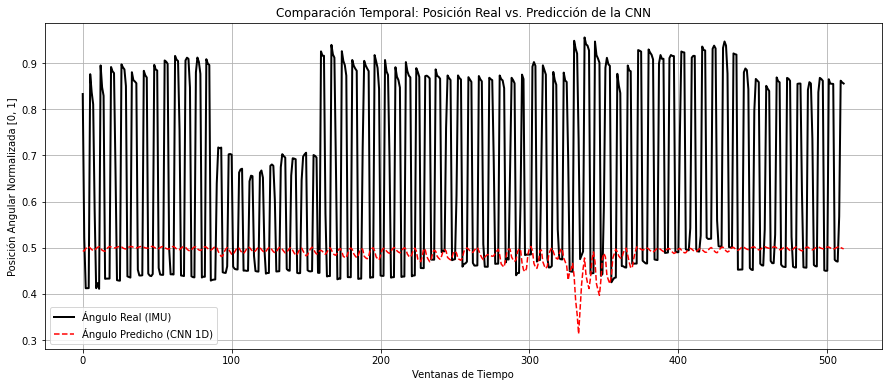

In [172]:

# 1. Hacer las predicciones con el set de prueba
predicciones_angulo = modelo_emg.predict(X_test)

# 2. Graficar los resultados (Graficaremos las primeras 1000 muestras para apreciarlo bien)
MUESTRAS_A_GRAFICAR = 1000

plt.figure(figsize=(15, 6))
plt.plot(y_test[:MUESTRAS_A_GRAFICAR], label='Ángulo Real (IMU)', color='black', linewidth=2)
plt.plot(predicciones_angulo[:MUESTRAS_A_GRAFICAR], label='Ángulo Predicho (CNN 1D)', color='red', linestyle='--', linewidth=1.5)

plt.title('Comparación Temporal: Posición Real vs. Predicción de la CNN')
plt.xlabel('Ventanas de Tiempo')
plt.ylabel('Posición Angular Normalizada [0, 1]')
plt.legend()
plt.grid(True)
plt.show()

### 1.5 Windowing 2

In [174]:
# NUEVA FUNCIÓN DE VENTANEO COMPENSADA
def segmentar_en_ventanas_centro(datos_emg, datos_imu, tamano_ventana, desplazamiento):
    X_ventanas = []
    y_valores = []
    for i in range(0, len(datos_emg) - tamano_ventana + 1, desplazamiento):
        X_ventanas.append(datos_emg[i : i + tamano_ventana])
        
        # CAMBIO CLAVE: Tomamos el ángulo del CENTRO de la ventana para mitigar desfases
        indice_centro = i + (tamano_ventana // 2)
        y_valores.append(datos_imu[indice_centro])
    return np.array(X_ventanas), np.array(y_valores)

# Volver a segmentar (usando las variables continuas que ya tenías)
X_train, y_train = segmentar_en_ventanas_centro(X_train_continuo, y_train_continuo, TAMANO_VENTANA, DESPLAZAMIENTO)
X_test, y_test = segmentar_en_ventanas_centro(X_test_continuo, y_test_continuo, TAMANO_VENTANA, DESPLAZAMIENTO)

# ==============================================================================
# VERIFICACIÓN DE LAS DIMENSIONES FINALES
# ==============================================================================
print("--- Dimensiones Finales para la CNN 1D ---")
print(f"X_train (Entrenamiento): {X_train.shape} -> (Ventanas, Muestras por ventana, Canales)")
print(f"y_train (Etiquetas):     {y_train.shape} -> (Ventanas, Ángulo objetivo)")
print("-" * 50)
print(f"X_test  (Prueba):        {X_test.shape}")
print(f"y_test  (Etiquetas):     {y_test.shape}")

--- Dimensiones Finales para la CNN 1D ---
X_train (Entrenamiento): (2057, 200, 1) -> (Ventanas, Muestras por ventana, Canales)
y_train (Etiquetas):     (2057, 1) -> (Ventanas, Ángulo objetivo)
--------------------------------------------------
X_test  (Prueba):        (512, 200, 1)
y_test  (Etiquetas):     (512, 1)


In [175]:
tf.keras.backend.clear_session()

modelo_emg = models.Sequential(name="CNN1D_Ligera")

# Una sola capa convolucional para evitar que la señal se diluya
modelo_emg.add(layers.Conv1D(filters=16, kernel_size=15, activation='relu', 
                             input_shape=(TAMANO_VENTANA, 1), padding='same'))
modelo_emg.add(layers.MaxPooling1D(pool_size=4)) # Reducción más agresiva

# Directo a aplanar y conectar a la salida
modelo_emg.add(layers.Flatten())
modelo_emg.add(layers.Dense(16, activation='relu'))
modelo_emg.add(layers.Dense(1, activation='linear')) # Predicción del ángulo

modelo_emg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), # Subimos un poco el learning rate
    loss='mse', # Cambiamos a MSE para forzarla a castigar fuertemente quedarse en 0.5
    metrics=['mae']
)

# Entrena de nuevo con tus mismos comandos de model.fit (puedes omitir el early stopping esta vez para ver qué hace en 30 épocas fijas)
modelo_emg.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=16)

C:\Users\dilp9\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0865 - mae: 0.2298 - val_loss: 0.0977 - val_mae: 0.2309
Epoch 2/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0660 - mae: 0.2008 - val_loss: 0.0982 - val_mae: 0.2305
Epoch 3/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0637 - mae: 0.1986 - val_loss: 0.0716 - val_mae: 0.2074
Epoch 4/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0630 - mae: 0.1984 - val_loss: 0.0693 - val_mae: 0.2130
Epoch 5/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0627 - mae: 0.1933 - val_loss: 0.0886 - val_mae: 0.2187
Epoch 6/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0641 - mae: 0.1973 - val_loss: 0.1000 - val_mae: 0.2340
Epoch 7/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0627 - mae: 0.1951 - val_loss: 0.1143 - val_mae: 0.2603
Epoch 8/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0610 - mae: 0.1920 - val_loss: 0.0830 - val_mae: 0.2143
Epoch 9/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step 

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


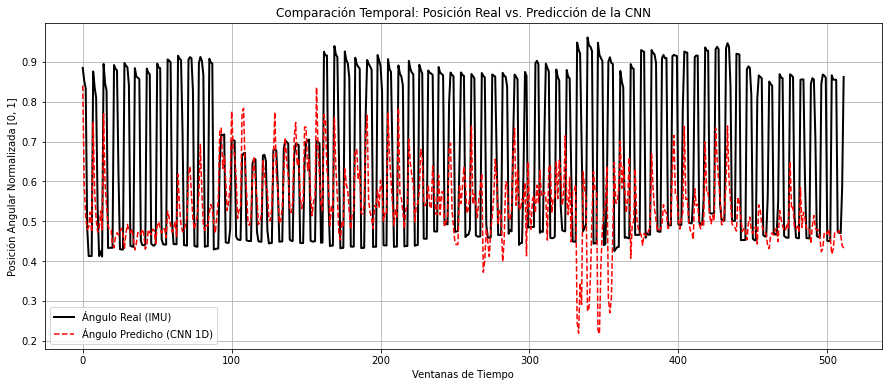

In [176]:
# 1. Hacer las predicciones con el set de prueba
predicciones_angulo = modelo_emg.predict(X_test)

# 2. Graficar los resultados (Graficaremos las primeras 1000 muestras para apreciarlo bien)
MUESTRAS_A_GRAFICAR = 1000

plt.figure(figsize=(15, 6))
plt.plot(y_test[:MUESTRAS_A_GRAFICAR], label='Ángulo Real (IMU)', color='black', linewidth=2)
plt.plot(predicciones_angulo[:MUESTRAS_A_GRAFICAR], label='Ángulo Predicho (CNN 1D)', color='red', linestyle='--', linewidth=1.5)

plt.title('Comparación Temporal: Posición Real vs. Predicción de la CNN')
plt.xlabel('Ventanas de Tiempo')
plt.ylabel('Posición Angular Normalizada [0, 1]')
plt.legend()
plt.grid(True)
plt.show()